In [155]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt
%matplotlib inline


In [156]:
day_df = pd.read_csv("C:/Users/harsh/Documents/infosys/Dataset exploration/day.csv")
hour_df = pd.read_csv("C:/Users/harsh/Documents/infosys/Dataset exploration/hour.csv")


In [157]:
def clean_dataset(df):
    df = df.copy()
    drop_cols = ["casual", "registered"]
    return df.drop(columns=drop_cols, errors="ignore")


FEATURE ENGINEERING 


In [158]:
def hour_feature_engineering(df):
    df = df.copy()

    # ---------- DATE ----------
    df["dteday"] = pd.to_datetime(df["dteday"])

    # ---------- WEEKEND ----------
    df["is_weekend"] = df["weekday"].isin([0, 6]).astype(int)

    # ---------- PART OF DAY ----------
    def part_of_day(hr):
        if 5 <= hr <= 11:
            return "Morning"
        elif 12 <= hr <= 16:
            return "Afternoon"
        elif 17 <= hr <= 21:
            return "Evening"
        else:
            return "Night"

    df["part_of_day"] = df["hr"].apply(part_of_day)

    # ---------- PEAK HOURS ----------
    df["is_peak_hour"] = df["hr"].isin([7, 8, 9, 17, 18, 19]).astype(int)
    df["is_night"] = df["hr"].isin([22, 23, 0, 1, 2, 3, 4]).astype(int)

    # ---------- CYCLICAL TIME ----------
    df["hr_sin"] = np.sin(2 * np.pi * df["hr"] / 24)
    df["hr_cos"] = np.cos(2 * np.pi * df["hr"] / 24)

    df["mnth_sin"] = np.sin(2 * np.pi * (df["mnth"] - 1) / 12)
    df["mnth_cos"] = np.cos(2 * np.pi * (df["mnth"] - 1) / 12)

    df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)
    # ---------- WEATHER ----------
    df["heat_index"] = df["temp"] * df["hum"]
    df["wind_chill"] = df["temp"] - df["windspeed"] * 0.7
    df["bad_weather"] = df["weathersit"].isin([3, 4]).astype(int)

    df["weather_severity"] = (
        df["weathersit"] * 0.4 +
        df["windspeed"] * 0.3 +
        df["hum"] * 0.3
    )

    return df


In [159]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

def day_feature_engineering(df, use_lags=True):
    df = df.copy()

    # ---------- SORT BY DATE (MANDATORY) ----------
    df["dteday"] = pd.to_datetime(df["dteday"])
    df = df.sort_values("dteday")

    # ---------- BASIC TIME FEATURES ----------
    df["weekday"] = df["dteday"].dt.weekday
    df["is_weekend"] = df["weekday"].isin([0, 6]).astype(int)

    df["mnth_sin"] = np.sin(2 * np.pi * (df["mnth"] - 1) / 12)
    df["mnth_cos"] = np.cos(2 * np.pi * (df["mnth"] - 1) / 12)

    df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

    df["quarter"] = ((df["mnth"] - 1) // 3 + 1)
    df["is_peak_season"] = df["season"].isin([2, 3]).astype(int)

    # ---------- WEATHER INTERACTIONS ----------
    df["temp_humidity"] = df["temp"] * df["hum"]
    df["temp_windspeed"] = df["temp"] * df["windspeed"]

    df["weather_severity"] = (
        df["weathersit"] * 0.5 +
        df["windspeed"] * 0.3 +
        df["hum"] * 0.2
    )

    # ---------- LAG FEATURES (OPTIONAL) ----------
    if use_lags:
        df["cnt_lag_7"] = df["cnt"].shift(7)
        df["cnt_diff_7"] = df["cnt"] - df["cnt_lag_7"]
        df["rolling_mean_7"] = df["cnt"].shift(1).rolling(7).mean()
        # shift(1) avoids future leakage

    # ---------- DROP UNUSED ----------
    df.drop(columns=["instant", "dteday"], inplace=True, errors="ignore")

    # ---------- DROP NaNs ----------
    df.dropna(inplace=True)

    return df


In [160]:
hour_df_fe = hour_feature_engineering(hour_df)
day_df_fe  = day_feature_engineering(day_df)

hour_df_final = clean_dataset(hour_df_fe)
day_df_final  = clean_dataset(day_df_fe)


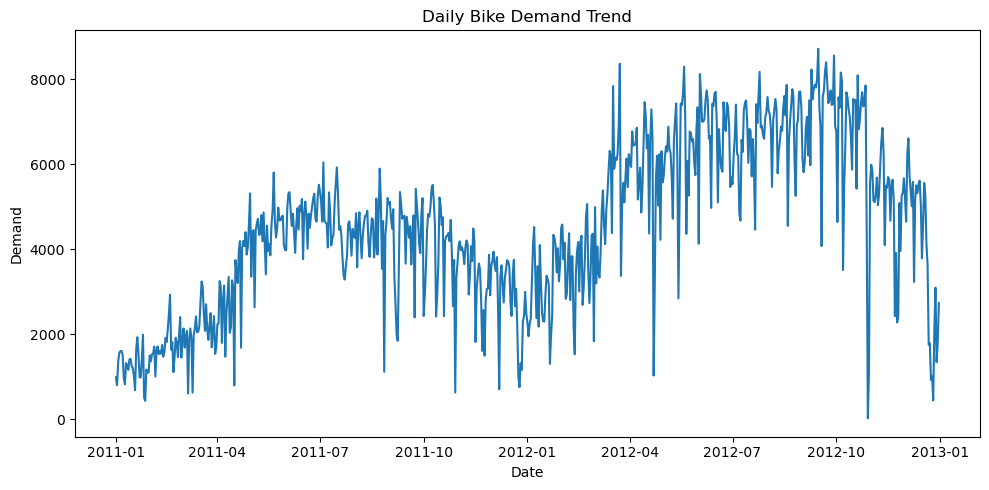

In [161]:
def plot_day_trend(df):
    plt.figure(figsize=(10,5))
    plt.plot(pd.to_datetime(df["dteday"]), df["cnt"])
    plt.title("Daily Bike Demand Trend")
    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.tight_layout()
    plt.show()
plot_day_trend(day_df)


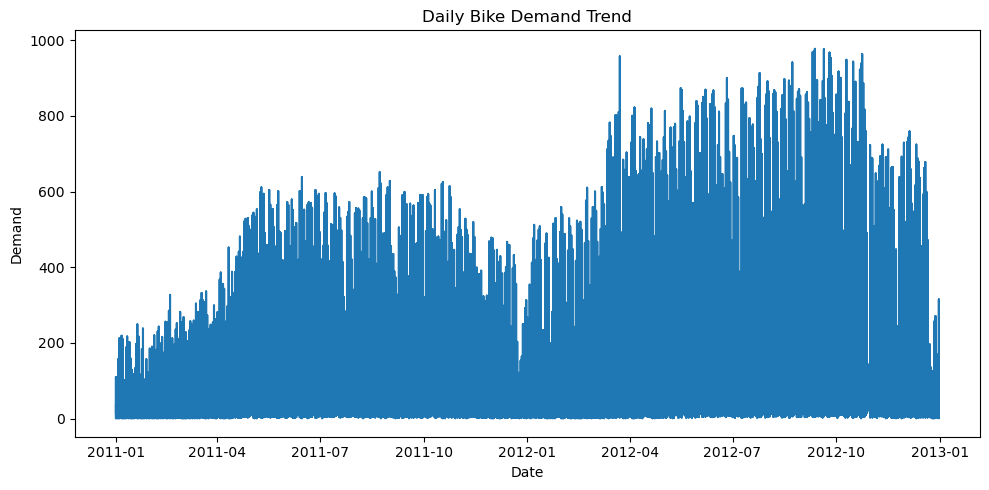

In [162]:
def plot_hour_pattern(df):
    avg = df.groupby("hr")["cnt"].mean()
    plt.figure(figsize=(8,4))
    avg.plot()
    plt.title("Average Hourly Demand")
    plt.xlabel("Hour")
    plt.ylabel("Demand")
    plt.grid(True)
    plt.show()
plot_day_trend(hour_df)

In [163]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import lightgbm as lgb
import xgboost as xgb
import pandas as pd
import numpy as np


In [164]:
def train_and_evaluate_models(df, dataset_name="hour"):
    print(f"\nTraining models for {dataset_name.upper()} dataset")

    X = df.drop(columns=["cnt"], errors="ignore")
    X = X.select_dtypes(include=["number"])
    y = df["cnt"]

    split_idx = int(len(df)*0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
        "XGBoost": xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42),
        "LightGBM": lgb.LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=63, max_depth=10, min_data_in_leaf=2, subsample=0.8, colsample_bytree=0.8)
    }

    trained_models = {}  # <<< ADD THIS

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        trained_models[name] = model   # <<< STORE TRAINED MODEL

        y_pred = model.predict(X_test)
        results.append({
            "Model": name,
            "R2": r2_score(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "MAE": mean_absolute_error(y_test, y_pred)
        })
        print(f"{name} trained")

    results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
    return results_df, trained_models, X_train, X_test, y_train, y_test


In [165]:
hour_results, trained_hour_models, X_train_hour, X_test_hour, y_train_hour, y_test_hour = train_and_evaluate_models(hour_df_final, "hour")



Training models for HOUR dataset
Linear Regression trained
Random Forest trained
Gradient Boosting trained
XGBoost trained
[LightGBM] [Warning] min_data_in_leaf is set=2, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2
[LightGBM] [Warning] min_data_in_leaf is set=2, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001445 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1378
[LightGBM] [Info] Number of data points in the train set: 13903, number of used features: 26
[LightGBM] [Info] Start training from score 174.639143
[LightGBM] [Warning] min_data_in_leaf is set=2, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2
LightGBM trained


In [166]:
day_results, trained_day_models, X_train_day, X_test_day, y_train_day, y_test_day = train_and_evaluate_models(day_df_final, "day")



Training models for DAY dataset
Linear Regression trained
Random Forest trained
Gradient Boosting trained
XGBoost trained
[LightGBM] [Warning] min_data_in_leaf is set=2, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2
[LightGBM] [Warning] min_data_in_leaf is set=2, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000759 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2015
[LightGBM] [Info] Number of data points in the train set: 579, number of used features: 24
[LightGBM] [Info] Start training from score 4198.784111
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

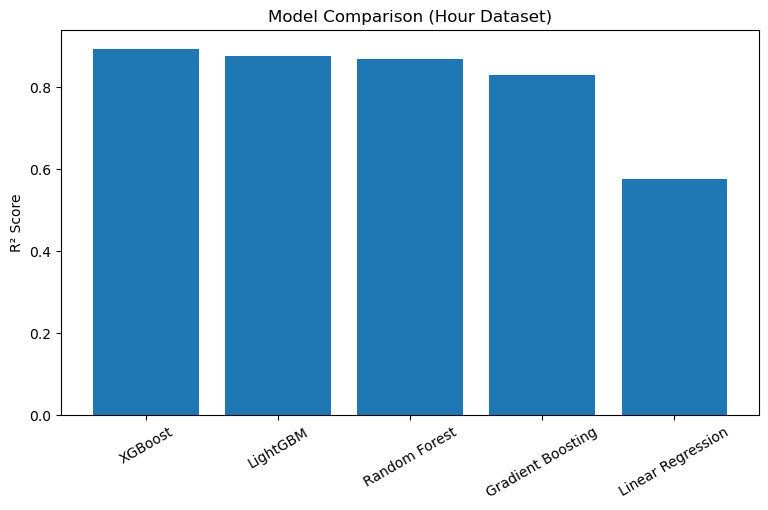

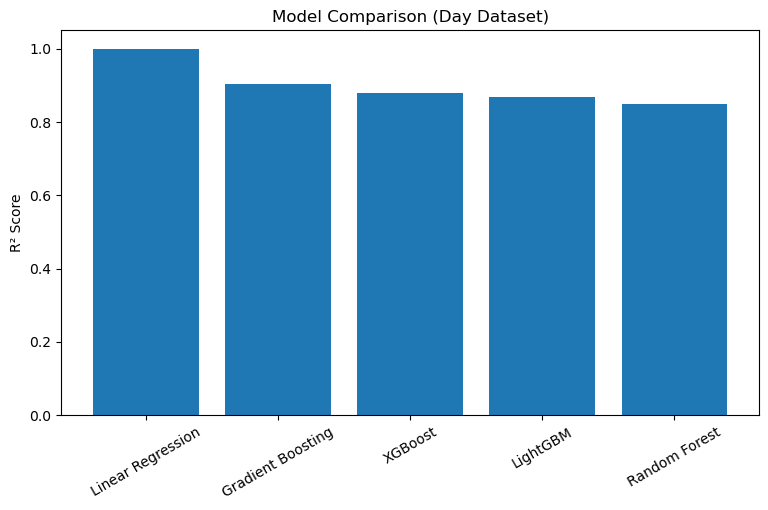

In [167]:
plt.figure(figsize=(9,5))
plt.bar(hour_results["Model"], hour_results["R2"])
plt.xticks(rotation=30)
plt.ylabel("R² Score")
plt.title("Model Comparison (Hour Dataset)")
plt.show()

plt.figure(figsize=(9,5))
plt.bar(day_results["Model"], day_results["R2"])
plt.xticks(rotation=30)
plt.ylabel("R² Score")
plt.title("Model Comparison (Day Dataset)")
plt.show()


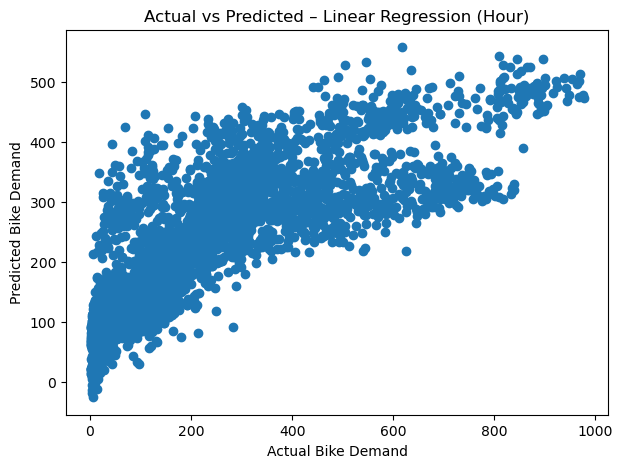

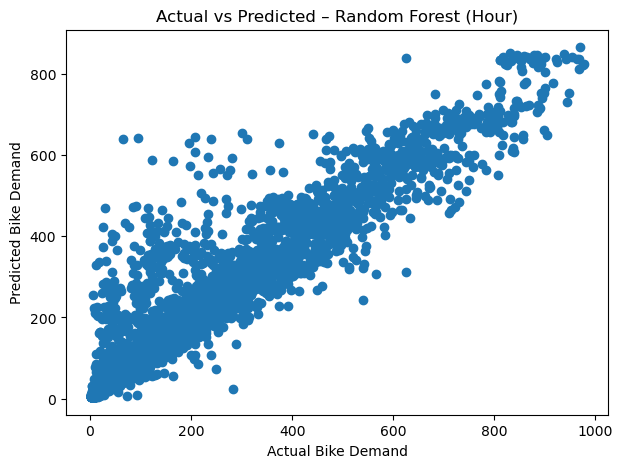

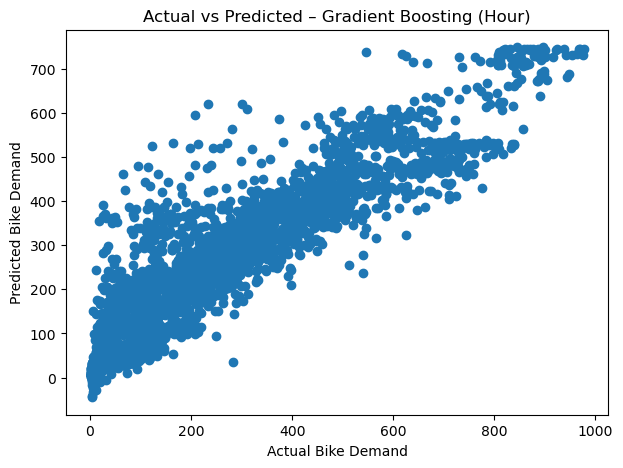

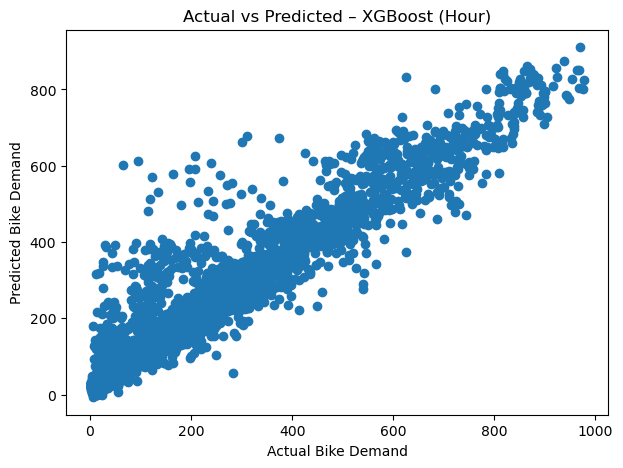

[LightGBM] [Warning] min_data_in_leaf is set=2, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2


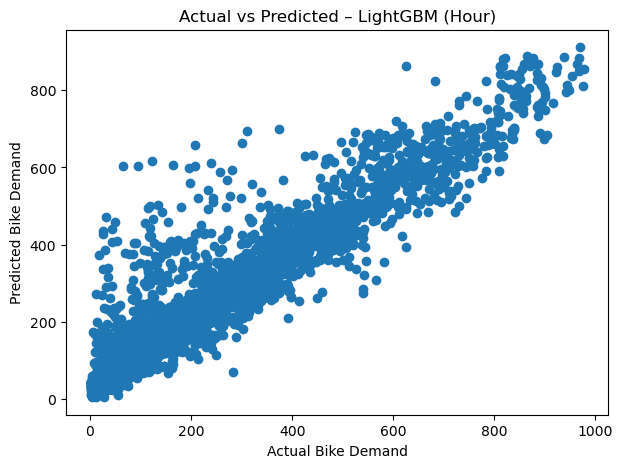

In [168]:
for name, model in trained_hour_models.items():
    y_pred = model.predict(X_test_hour)

    plt.figure(figsize=(7,5))
    plt.scatter(y_test_hour, y_pred)
    plt.xlabel("Actual Bike Demand")
    plt.ylabel("Predicted Bike Demand")
    plt.title(f"Actual vs Predicted – {name} (Hour)")
    plt.show()


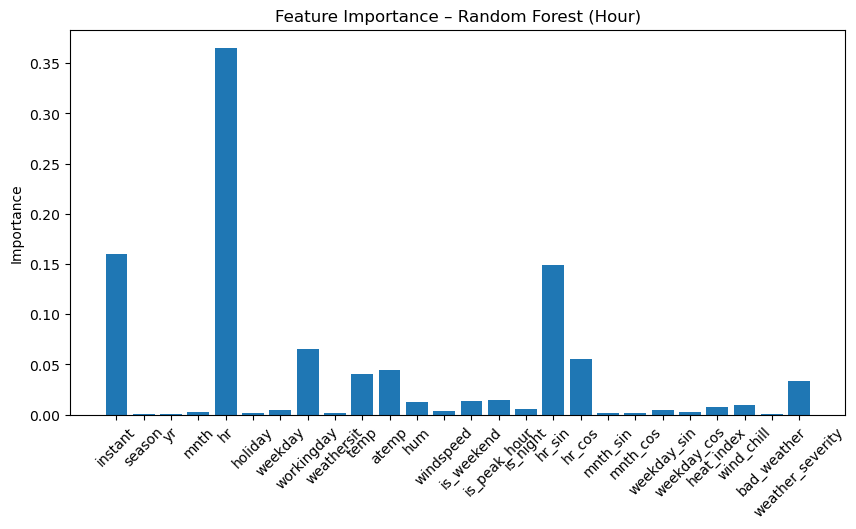

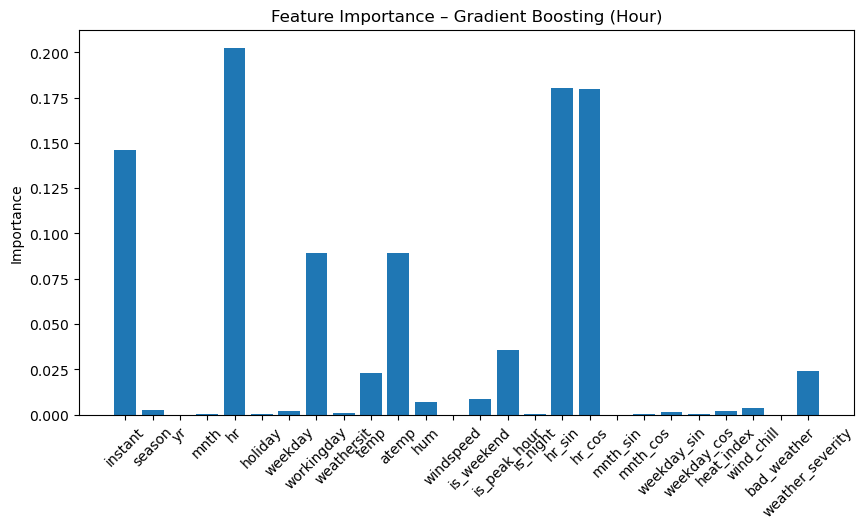

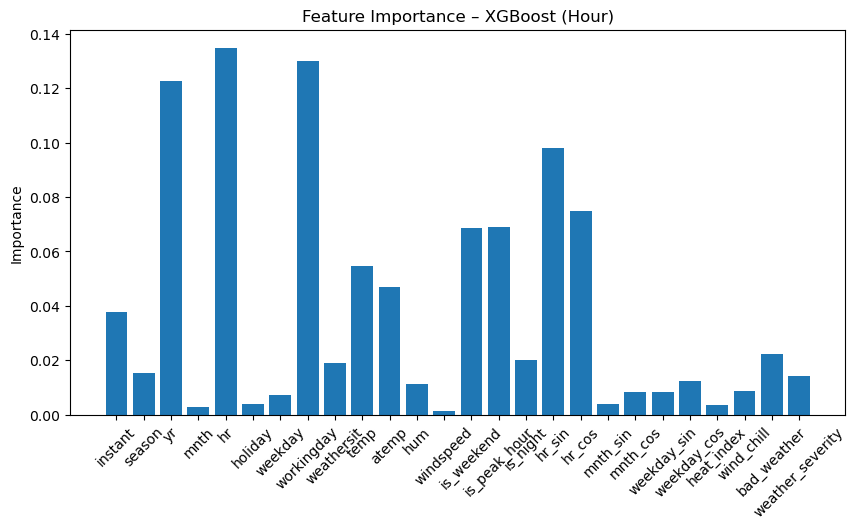

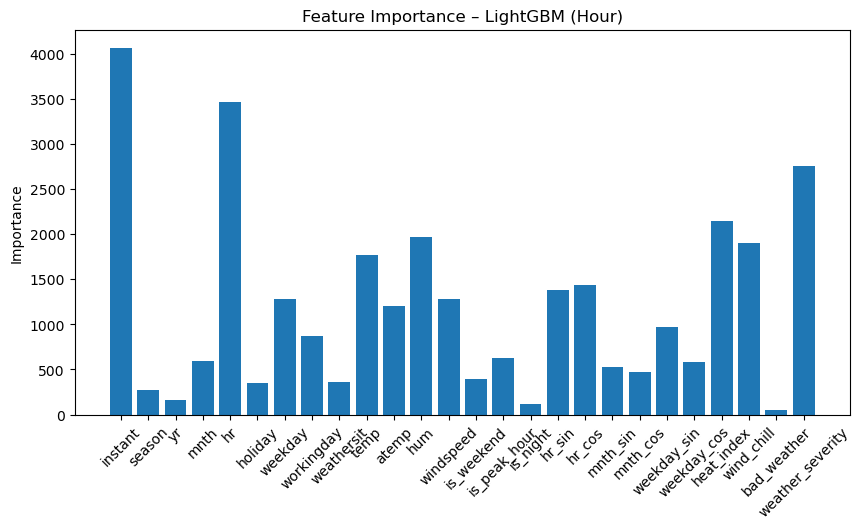

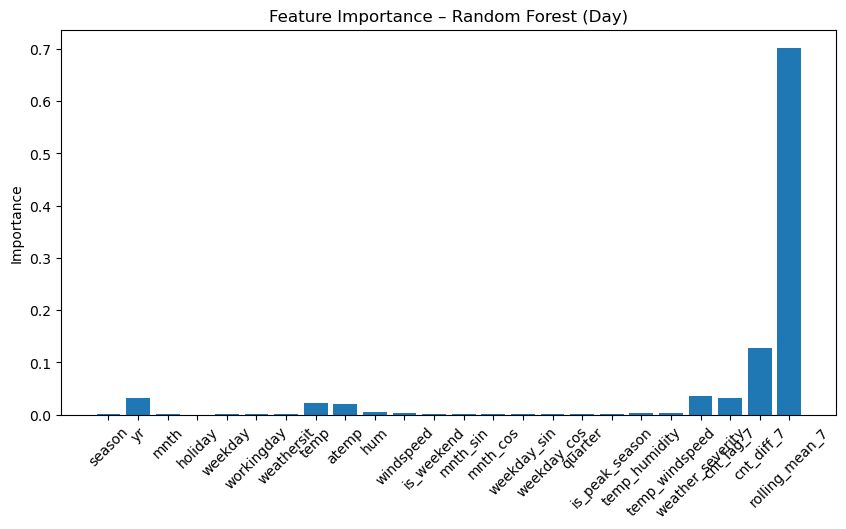

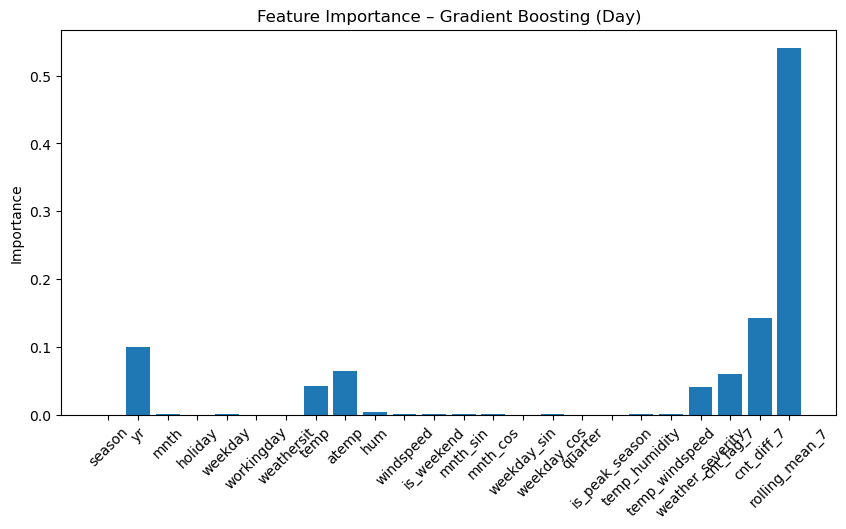

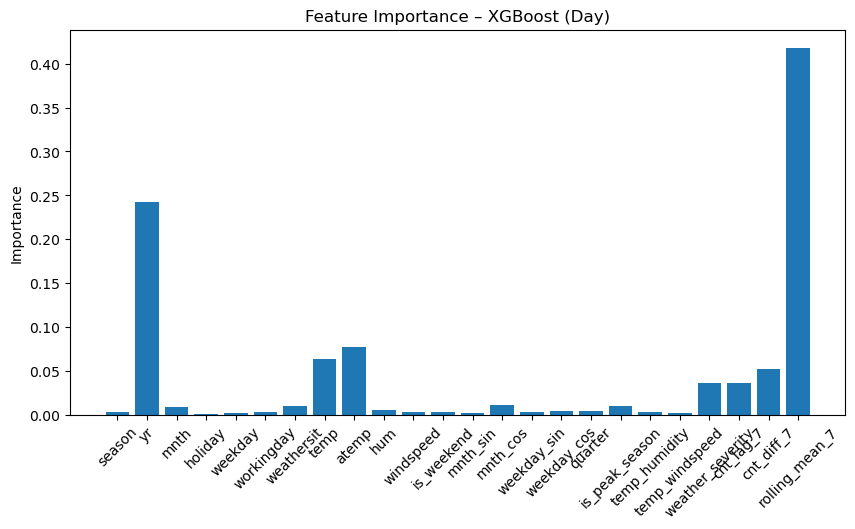

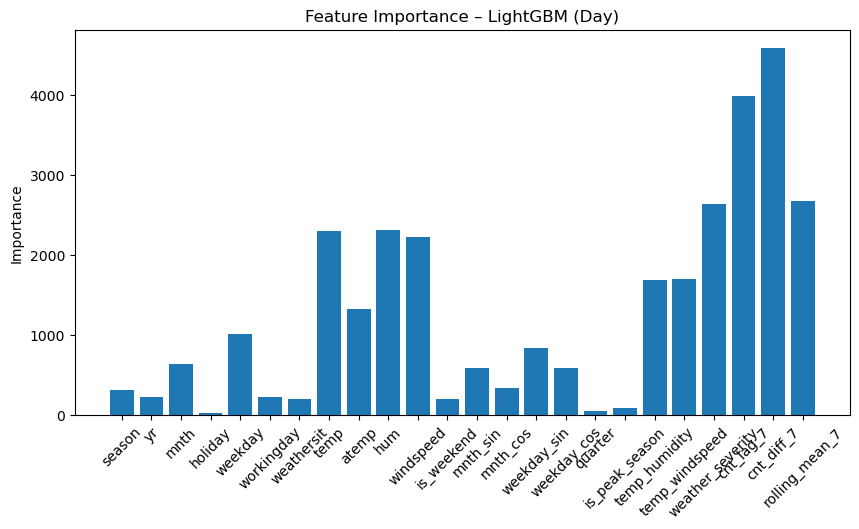

In [169]:
# Hour
for name, model in trained_hour_models.items():
    if hasattr(model, "feature_importances_"):
        plt.figure(figsize=(10,5))
        plt.bar(X_train_hour.columns, model.feature_importances_)
        plt.xticks(rotation=45)
        plt.ylabel("Importance")
        plt.title(f"Feature Importance – {name} (Hour)")
        plt.show()

# Day
for name, model in trained_day_models.items():
    if hasattr(model, "feature_importances_"):
        plt.figure(figsize=(10,5))
        plt.bar(X_train_day.columns, model.feature_importances_)
        plt.xticks(rotation=45)
        plt.ylabel("Importance")
        plt.title(f"Feature Importance – {name} (Day)")
        plt.show()


In [170]:
for name, model in trained_hour_models.items():
    if hasattr(model, "feature_importances_"):
        imp_df = pd.DataFrame({"Feature": X_train_hour.columns, "Importance": model.feature_importances_})
        print(f"\nTop 5 Features – {name} (Hour)")
        print(imp_df.sort_values(by="Importance", ascending=False).head())

for name, model in trained_day_models.items():
    if hasattr(model, "feature_importances_"):
        imp_df = pd.DataFrame({"Feature": X_train_day.columns, "Importance": model.feature_importances_})
        print(f"\nTop 5 Features – {name} (Day)")
        print(imp_df.sort_values(by="Importance", ascending=False).head())



Top 5 Features – Random Forest (Hour)
       Feature  Importance
4           hr    0.365250
0      instant    0.159599
16      hr_sin    0.148556
7   workingday    0.064956
17      hr_cos    0.054991

Top 5 Features – Gradient Boosting (Hour)
       Feature  Importance
4           hr    0.202446
16      hr_sin    0.180513
17      hr_cos    0.179817
0      instant    0.146101
7   workingday    0.089433

Top 5 Features – XGBoost (Hour)
       Feature  Importance
4           hr    0.134772
7   workingday    0.130109
2           yr    0.122648
16      hr_sin    0.098122
17      hr_cos    0.074849

Top 5 Features – LightGBM (Hour)
             Feature  Importance
0            instant        4063
4                 hr        3464
25  weather_severity        2760
22        heat_index        2144
11               hum        1973

Top 5 Features – Random Forest (Day)
             Feature  Importance
23    rolling_mean_7    0.701648
22        cnt_diff_7    0.127813
20  weather_severity    0.0352

In [171]:
print("=== Hour Dataset Model Metrics ===")
for i, row in hour_results.iterrows():
    print(f"Model: {row['Model']}")
    print(f"R² Score: {row['R2']:.4f}")
    print(f"RMSE: {row['RMSE']:.4f}")
    print(f"MAE: {row['MAE']:.4f}")
    print("-"*35)


=== Hour Dataset Model Metrics ===
Model: XGBoost
R² Score: 0.8936
RMSE: 71.9279
MAE: 44.7644
-----------------------------------
Model: LightGBM
R² Score: 0.8755
RMSE: 77.7903
MAE: 49.0309
-----------------------------------
Model: Random Forest
R² Score: 0.8686
RMSE: 79.9201
MAE: 48.5274
-----------------------------------
Model: Gradient Boosting
R² Score: 0.8295
RMSE: 91.0497
MAE: 61.2589
-----------------------------------
Model: Linear Regression
R² Score: 0.5759
RMSE: 143.5945
MAE: 103.7329
-----------------------------------


In [172]:
print("=== Day Dataset Model Metrics ===")
for i, row in day_results.iterrows():
    print(f"Model: {row['Model']}")
    print(f"R² Score: {row['R2']:.4f}")
    print(f"RMSE: {row['RMSE']:.4f}")
    print(f"MAE: {row['MAE']:.4f}")
    print("-"*35)


=== Day Dataset Model Metrics ===
Model: Linear Regression
R² Score: 1.0000
RMSE: 0.0000
MAE: 0.0000
-----------------------------------
Model: Gradient Boosting
R² Score: 0.9025
RMSE: 586.5942
MAE: 448.0072
-----------------------------------
Model: XGBoost
R² Score: 0.8795
RMSE: 652.3656
MAE: 486.1356
-----------------------------------
Model: LightGBM
R² Score: 0.8686
RMSE: 681.1515
MAE: 524.8533
-----------------------------------
Model: Random Forest
R² Score: 0.8486
RMSE: 731.0878
MAE: 552.0440
-----------------------------------


In [173]:
print("=== Hour Dataset ===")
display(hour_results.style.format({
    "R2": "{:.4f}",
    "RMSE": "{:.4f}",
    "MAE": "{:.4f}"
}))

print("=== Day Dataset ===")
display(day_results.style.format({
    "R2": "{:.4f}",
    "RMSE": "{:.4f}",
    "MAE": "{:.4f}"
}))


=== Hour Dataset ===


,Model,R2,RMSE,MAE
3,XGBoost,0.8936,71.9279,44.7644
4,LightGBM,0.8755,77.7903,49.0309
1,Random Forest,0.8686,79.9201,48.5274
2,Gradient Boosting,0.8295,91.0497,61.2589
0,Linear Regression,0.5759,143.5945,103.7329


=== Day Dataset ===


,Model,R2,RMSE,MAE
0,Linear Regression,1.0000,0.0000,0.0000
2,Gradient Boosting,0.9025,586.5942,448.0072
3,XGBoost,0.8795,652.3656,486.1356
4,LightGBM,0.8686,681.1515,524.8533
1,Random Forest,0.8486,731.0878,552.0440


In [174]:
# Sort by R² descending
hour_results_sorted = hour_results.sort_values("R2", ascending=False)

# Get best model
best_hour_model_name = hour_results_sorted.iloc[0]["Model"]
best_hour_r2 = hour_results_sorted.iloc[0]["R2"]

print(f"Best Hour Model: {best_hour_model_name}")
print(f"R² Score: {best_hour_r2:.4f}")


Best Hour Model: XGBoost
R² Score: 0.8936


In [175]:
# Sort by R² descending
hour_results_sorted = hour_results.sort_values("R2", ascending=False)

# Get best model
best_hour_model_name = hour_results_sorted.iloc[0]["Model"]
best_hour_r2 = hour_results_sorted.iloc[0]["R2"]

print(f"Best Hour Model: {best_hour_model_name}")
print(f"R² Score: {best_hour_r2:.4f}")


Best Hour Model: XGBoost
R² Score: 0.8936


In [176]:
day_results_sorted = day_results.sort_values("R2", ascending=False)

best_day_model_name = day_results_sorted.iloc[0]["Model"]
best_day_r2 = day_results_sorted.iloc[0]["R2"]

print(f"Best Day Model: {best_day_model_name}")
print(f"R² Score: {best_day_r2:.4f}")


Best Day Model: Linear Regression
R² Score: 1.0000


In [177]:
best_hour_model = trained_hour_models[best_hour_model_name]
best_day_model = trained_day_models[best_day_model_name]


In [178]:
import pickle
with open("best_hour_model.pkl", "wb") as f:
    pickle.dump(best_hour_model, f)

print("Best Hour model saved as best_hour_model.pkl")


Best Hour model saved as best_hour_model.pkl


In [179]:
with open("best_day_model.pkl", "wb") as f:
    pickle.dump(best_day_model, f)

print("Best Day model saved as best_day_model.pkl")


Best Day model saved as best_day_model.pkl


In [180]:
import pickle

# Load Hour Model
hour_model = pickle.load(open("best_hour_model.pkl", "rb"))

# Load Day Model
day_model = pickle.load(open("best_day_model.pkl", "rb"))

# Example prediction
y_pred = hour_model.predict(X_test_hour)
